# SKA-like drift scan: TOD simulation + map-making

First-look notebook for a **drift-scan** strategy with an SKA-Mid-like single dish
(15 m, Karoo site) at **350 MHz** (SKA-Mid Band 1 low end). Unlike the DSA azimuth
scan (telescope sweeps) and stop-and-stare (telescope tracks), here the telescope is
**parked** at a fixed (Az, El) and the sky drifts through the beam at 15°/hr in RA:

- Fixed **az = 0°** (north-facing meridian); elevation stepped once per night
  (52° / 50° / 48° → Dec strips at 7.4° / 9.4° / 11.4°, half-beam spacing).
- Consecutive nights are offset by one **sidereal day**, so every night covers the
  same RA window — the map-maker sees the same strip through 3 beam-center Decs.
- Forward model via `limTOD.TODSim.generate_TOD`, inverse via `limTOD.HPW_mapmaking`.

**Two beam models**, run through the identical pipeline so their effect is isolated:

1. **Gaussian** — FWHM = 1.22 λ/D ≈ 4.0°, no sidelobes (the idealised case).
2. **Tapered aperture** ("realistic Airy") — full circular-aperture diffraction
   pattern with a −14 dB edge taper: FWHM ≈ 3.8°, sidelobe rings every ~3.3°
   (first at −23 dB), ~1% of beam power beyond 10° off-axis. Drift scans are the
   worst case for sidelobes: with the dish parked, off-axis structure sweeps through
   the sidelobe rings coherently and nothing cross-links it away.

**Drift-scan caveat on high-pass filtering.** The sky signal of a drift scan lives at
very low temporal frequencies: one beam crossing takes FWHM / 15°hr⁻¹ ≈ 16 min, i.e.
the signal band is ≲ 1 mHz — right on top of the 1/f knee (`fc ≈ 1.1 mHz` in the
default flicker model). The 30 mHz cutoff used by the DSA azimuth-scan notebooks would
erase the sky entirely here. Each beam's map is therefore solved **without** the
high-pass filter and, for comparison, **with** a very low 2 mHz cutoff.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'DSA')))

import pickle
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import EarthLocation
from astropy import units as u

from limTOD import TODSim, HPW_mapmaking
from ska_common import (SKA_LAT, SKA_LON, SKA_HGT, ska_beam_func,
                        gdsm_equatorial_sky_model,
                        ska_airy_beam_func, ska_beam_fwhm_deg,
                        tapered_aperture_fwhm_deg, tapered_aperture_profile,
                        drift_scan_night, azel_to_radec, save_results_pdf)
from dsa_vis import plot_map_compare, plot_patch


In [2]:
# Frequency: SKA-Mid Band 1 low end. Both beam models are chromatic
# (they scale with λ/D, D = 15 m), so this choice sets the resolution.
freq_list = [350]  # MHz

# The two beam models, keyed by the tag used in cache filenames.
BEAMS = {
    "gauss": dict(func=ska_beam_func,
                  fwhm=ska_beam_fwhm_deg(freq_list[0]),
                  label="Gaussian (1.22 λ/D)"),
    "airy": dict(func=ska_airy_beam_func,
                 fwhm=tapered_aperture_fwhm_deg(freq_list[0]),
                 label="Tapered aperture (−14 dB edge taper)"),
}
for tag, b in BEAMS.items():
    print(f"{tag:6s}: FWHM = {b['fwhm']:.2f} deg")

# Same resolution regime as the DSA notebooks (FWHM ≈ 4°), so nside = 64
# (~0.9°/pix) resolves the beam — and its ~3.3°-spaced sidelobe rings —
# while keeping the per-sample rotation cheap.
sky_Nside = 64
beam_Nside = 64
sky_Nside_map = 64

# Beam-edge truncation fraction; re-used as the mapmaker's
# beam_truncate_frac_thres so forward and inverse agree on beam support.
# 1e-5 (−50 dB) keeps the tapered-aperture sidelobe rings — the DSA
# notebooks' 1e-3 (−30 dB) would amputate everything past the first ring.
truncate_frac_thres = 1e-5

# Noise seed. Reseeded as SEED + night before each night's draw, with the
# SAME seed for both beams — so gauss and airy see identical 1/f and white
# noise realizations and their comparison isolates the beam alone.
SEED = 0


gauss : FWHM = 3.99 deg
airy  : FWHM = 3.84 deg


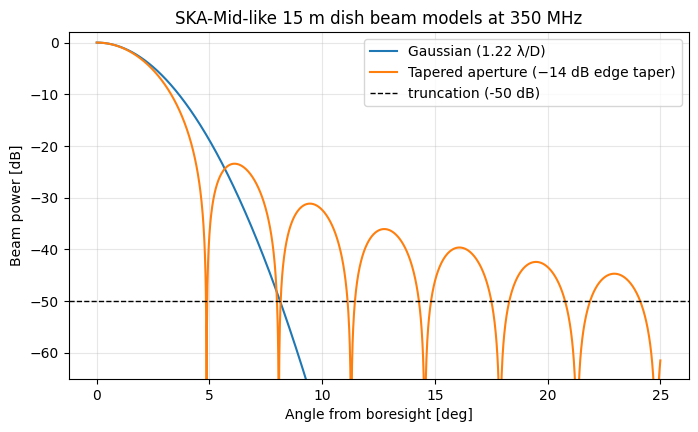

In [3]:
# Beam comparison: radial power profiles in dB. The Gaussian dives
# monotonically; the tapered aperture rings every ~λ/D. The dashed line
# marks the truncation threshold applied in the simulation.
theta = np.linspace(0.0, 25.0, 2001)
fwhm_g = BEAMS["gauss"]["fwhm"]
sigma_g = fwhm_g / (2 * np.sqrt(2 * np.log(2)))
prof_gauss = np.exp(-0.5 * (theta / sigma_g) ** 2)
prof_airy = tapered_aperture_profile(theta, freq_list[0])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(theta, 10 * np.log10(np.maximum(prof_gauss, 1e-12)),
        label=BEAMS["gauss"]["label"])
ax.plot(theta, 10 * np.log10(np.maximum(prof_airy, 1e-12)),
        label=BEAMS["airy"]["label"])
ax.axhline(10 * np.log10(truncate_frac_thres), color="k", ls="--", lw=1,
           label=f"truncation ({10 * np.log10(truncate_frac_thres):.0f} dB)")
ax.set_xlabel("Angle from boresight [deg]")
ax.set_ylabel("Beam power [dB]")
ax.set_ylim(-65, 2)
ax.set_title(f"SKA-Mid-like 15 m dish beam models at {freq_list[0]} MHz")
ax.legend()
ax.grid(alpha=0.3)
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/beam_profiles.png", dpi=200, bbox_inches="tight")
plt.show()


## Drift-scan pointing design

One hour per night at `dt = 2 s` (1800 samples/night, 5400 total) covers ~15° of RA
per night. `START_UTC` puts LST ≈ 151° at the start, so the strip runs
RA ≈ 151°–166° at Dec ≈ 7°–11° — galactic latitude b ≈ +50°, safely off-plane.


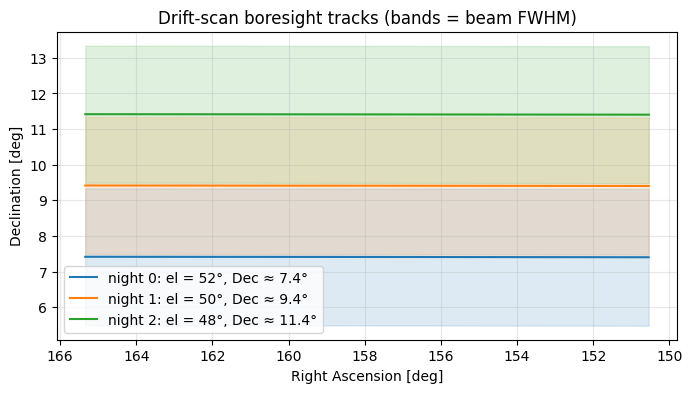

In [4]:
DRIFT_AZ = 0.0                    # parked on the meridian, facing north
ELEVATIONS = [52.0, 50.0, 48.0]   # one per night; 2° ≈ half-beam Dec steps
NIGHT_DURATION_S = 3600.0
DT = 2.0
START_UTC = "2024-04-15 19:00:00"  # LST ≈ 151° at Karoo

site = EarthLocation(lat=SKA_LAT * u.deg, lon=SKA_LON * u.deg,
                     height=SKA_HGT * u.m)

nights = []
for night, el in enumerate(ELEVATIONS):
    tlist, azlist = drift_scan_night(NIGHT_DURATION_S, dt=DT,
                                     night=night, azimuth_deg=DRIFT_AZ)
    nights.append(dict(night=night, el=el, tlist=tlist, azlist=azlist))

# Boresight tracks (subsampled ×30 — astropy transforms are slow per-sample)
fwhm_ref = BEAMS["airy"]["fwhm"]
fig, ax = plt.subplots(figsize=(8, 4))
for n in nights:
    ra, dec = azel_to_radec(DRIFT_AZ, n["el"], n["tlist"][::30],
                            START_UTC, site)
    line, = ax.plot(ra, dec, lw=1.5,
                    label=f"night {n['night']}: el = {n['el']:.0f}°, "
                          f"Dec ≈ {dec.mean():.1f}°")
    ax.fill_between(ra, dec - fwhm_ref / 2, dec + fwhm_ref / 2,
                    alpha=0.15, color=line.get_color())
ax.set_xlabel("Right Ascension [deg]")
ax.set_ylabel("Declination [deg]")
ax.invert_xaxis()  # RA increases to the left
ax.set_title("Drift-scan boresight tracks (bands = beam FWHM)")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig("figures/drift_tracks.png", dpi=200, bbox_inches="tight")
plt.show()


[gauss] loaded 3 cached TODs from simulated_TODs_ska_drift_gauss.npz
[airy] loaded 3 cached TODs from simulated_TODs_ska_drift_airy.npz


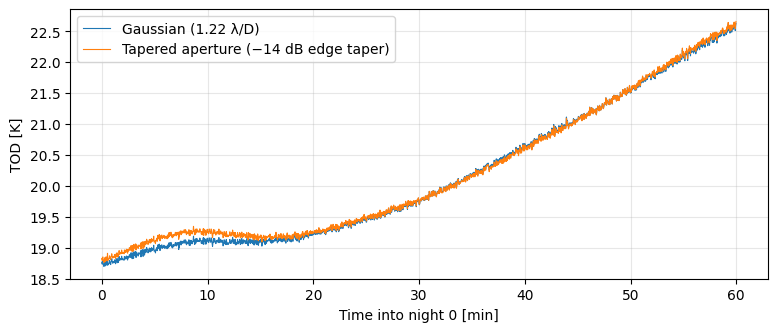

In [5]:
# Simulate one TOD per night per beam model (cached per beam).
# Noise: default 1/f flicker gain noise + fractional white noise.
WHITE_VAR = 2.5e-6  # fractional white-noise variance (as mm_example.ipynb)

tod_data = {}  # tag -> dict of TOD/LST/az/el groups
for tag, b in BEAMS.items():
    cache = f"simulated_TODs_ska_drift_{tag}.npz"
    try:
        data = np.load(cache, allow_pickle=True)
        tod_data[tag] = dict(
            TOD_group=[np.asarray(t, np.float64) for t in data["TOD_group"]],
            LST_deg_list_group=[np.asarray(x, np.float64)
                                for x in data["LST_deg_list_group"]],
            azimuth_deg_list_group=[np.asarray(x, np.float64)
                                    for x in data["azimuth_deg_list_group"]],
            elevation_deg_list_group=[np.asarray(x, np.float64)
                                      for x in data["elevation_deg_list_group"]],
        )
        print(f"[{tag}] loaded {len(tod_data[tag]['TOD_group'])} cached "
              f"TODs from {cache}")
        continue
    except (FileNotFoundError, KeyError):
        pass

    tod_sim = TODSim(
        ant_latitude_deg=SKA_LAT,
        ant_longitude_deg=SKA_LON,
        ant_height_m=SKA_HGT,
        beam_func=b["func"],
        sky_func=gdsm_equatorial_sky_model,
        beam_nside=beam_Nside,
        sky_nside=sky_Nside,
    )
    groups = dict(TOD_group=[], LST_deg_list_group=[],
                  azimuth_deg_list_group=[], elevation_deg_list_group=[])
    print(f"[{tag}] generating simulated TODs (one per night)...")
    for n in nights:
        # Same seed for the same night across beams: identical noise
        # realizations, so the beam comparison isolates the beam alone.
        np.random.seed(SEED + n["night"])
        tod_array, _, _, lst_deg = tod_sim.generate_TOD(
            freq_list=freq_list,
            time_list=n["tlist"],
            azimuth_deg_list=n["azlist"],
            elevation_deg=n["el"],
            start_time_utc=START_UTC,
            white_noise_var=WHITE_VAR,
            return_LSTs=True,
            normalize_beam=False,
            truncate_frac_thres=truncate_frac_thres,
        )
        groups["TOD_group"].append(np.asarray(tod_array[0], np.float64))
        groups["LST_deg_list_group"].append(np.asarray(lst_deg, np.float64))
        groups["azimuth_deg_list_group"].append(
            np.asarray(n["azlist"], np.float64))
        groups["elevation_deg_list_group"].append(
            n["el"] * np.ones_like(groups["TOD_group"][-1]))
    np.savez(cache, freq_list=freq_list, **groups)
    tod_data[tag] = groups
    print(f"[{tag}] done! Saved to {cache}")

# Quick look at night 0: the slow ramp is the sky drifting through the
# beam; the wiggles are 1/f gain drift. The gauss/airy difference is the
# sidelobes picking up off-axis (mostly Galactic) emission.
fig, ax = plt.subplots(figsize=(9, 3.5))
for tag, b in BEAMS.items():
    ax.plot(nights[0]["tlist"] / 60.0, tod_data[tag]["TOD_group"][0],
            lw=0.8, label=b["label"])
ax.set_xlabel("Time into night 0 [min]")
ax.set_ylabel("TOD [K]")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig("figures/tod_night0.png", dpi=200, bbox_inches="tight")
plt.show()


In [6]:
# HPW mapmaker operator per beam (cached to .pkl).
mapmakers = {}
for tag, b in BEAMS.items():
    cache = f"mapmaker_ops_ska_drift_{tag}_ns{sky_Nside_map}.pkl"
    try:
        with open(cache, "rb") as f:
            mapmakers[tag] = pickle.load(f)
        print(f"[{tag}] loaded cached HPW_mapmaker operator from {cache}")
        continue
    except (FileNotFoundError, EOFError):
        pass
    beam_map = b["func"](freq=freq_list[0], nside=beam_Nside)
    mapmakers[tag] = HPW_mapmaking(
        beam_map=beam_map,
        LST_deg_list_group=tod_data[tag]["LST_deg_list_group"],
        lat_deg=SKA_LAT,
        azimuth_deg_list_group=tod_data[tag]["azimuth_deg_list_group"],
        elevation_deg_list_group=tod_data[tag]["elevation_deg_list_group"],
        threshold=0.05,
        nside_target=sky_Nside_map,
        beam_truncate_frac_thres=truncate_frac_thres,
    )
    with open(cache, "wb") as f:
        pickle.dump(mapmakers[tag], f)
    print(f"[{tag}] built HPW_mapmaker and cached to {cache}")

for tag, mm in mapmakers.items():
    print(f"[{tag}] pixel selection: {len(mm.pixel_indices)} pixels "
          f"at nside={sky_Nside_map}")


[gauss] loaded cached HPW_mapmaker operator from mapmaker_ops_ska_drift_gauss_ns64.pkl
[airy] loaded cached HPW_mapmaker operator from mapmaker_ops_ska_drift_airy_ns64.pkl
[gauss] pixel selection: 317 pixels at nside=64
[airy] pixel selection: 277 pixels at nside=64


## Map-making

Prior recipe follows `dsa_meerklass_scan.ipynb`: beam-smoothed truth as prior mean
(no sub-beam information; smoothed with each beam's own FWHM), `σ = std(truth)`, and
explicit per-sample noise variance `WHITE_VAR × (op_i @ truth)²` so the Wiener filter
doesn't fall back to its biased auto-estimate.

Six solves — {Gaussian, tapered aperture, **beam mismatch**} × {no HP, HP at 2 mHz}:

- **No high-pass** keeps all the sky signal, but 1/f drift maps straight into the
  RA direction (stripes along the drift).
- **HP at 2 mHz** sits just above the 1/f knee, but inevitably eats part of the
  ≲ 1 mHz drift signal too.
- The matched gauss-vs-airy difference isolates what *modelled* sidelobes cost:
  the forward data contain sidelobe pickup, and the operator deconvolves rings it
  knows about.
- **Beam mismatch** is the realistic survey scenario: TOD simulated with the
  tapered-aperture beam, but map made with the *Gaussian* operator — the sidelobe
  pickup in the data is unmodelled and lands in the map as a systematic. Because
  both beams share identical noise realizations (per-night seeding), the
  mismatch-vs-matched-airy difference is purely the unmodelled sidelobes.


In [7]:
sky_truth_full = gdsm_equatorial_sky_model(freq=freq_list[0], nside=sky_Nside_map)


def solve_both(mm, TOD_group, assumed_fwhm_deg):
    '''Solve {no HP, HP 2 mHz} with the standard prior/noise recipe.

    ``assumed_fwhm_deg`` is the FWHM of the beam the *operator* assumes —
    the prior mean is smoothed with that beam, as a real analysis would.
    '''
    pix = mm.pixel_indices
    sky_truth = sky_truth_full[pix]

    prior_mean = hp.smoothing(sky_truth_full,
                              fwhm=np.radians(assumed_fwhm_deg))[pix]
    prior_sigma_K = max(float(np.std(sky_truth)), 1e-3)
    prior_inv_cov = np.ones_like(sky_truth) / prior_sigma_K**2

    nv_floor = WHITE_VAR * (1e-3 * float(np.mean(sky_truth)))**2
    noise_variance = [WHITE_VAR * (np.asarray(op) @ sky_truth)**2 + nv_floor
                      for op in mm.Tsys_operators]

    common = dict(
        TOD_group=TOD_group,
        dtime=DT,
        Tsky_prior_mean=prior_mean,
        Tsky_prior_inv_cov_diag=prior_inv_cov,
        noise_variance=noise_variance,
        regularization=1e-12,
        return_full_cov=False,
    )
    est_noHP, _ = mm(**common)
    est_HP, _ = mm(
        **common,
        use_high_pass=True,
        cutoff_freq_group=np.array([2e-3] * len(TOD_group)),
        filter_order=2,
    )
    return {"no HP": est_noHP, "HP 2 mHz": est_HP}, sky_truth


# The three scenarios: (operator, TOD data, operator's assumed beam FWHM).
# "mismatch" = tapered-aperture sky seen through a Gaussian operator.
SCENARIOS = {
    "gauss": (mapmakers["gauss"], tod_data["gauss"], BEAMS["gauss"]["fwhm"]),
    "airy": (mapmakers["airy"], tod_data["airy"], BEAMS["airy"]["fwhm"]),
    "mismatch": (mapmakers["gauss"], tod_data["airy"], BEAMS["gauss"]["fwhm"]),
}
SCENARIO_PIX = {tag: mm.pixel_indices for tag, (mm, _, _) in SCENARIOS.items()}

results = {}   # (tag, hp_label) -> estimate
truths = {}    # tag -> truth on that scenario's pixel selection
for tag, (mm, data, fwhm) in SCENARIOS.items():
    solved, truths[tag] = solve_both(mm, data["TOD_group"], fwhm)
    for hp_label, est in solved.items():
        results[(tag, hp_label)] = est

rms_rows = []
print(f"{'scenario':10s} {'filter':10s} residual RMS")
for (tag, hp_label), est in results.items():
    rms = np.std(est - truths[tag]) * 1e3
    rms_rows.append((f"{tag} / {hp_label}", f"{rms:7.1f} mK"))
    print(f"{tag:10s} {hp_label:10s} {rms:8.1f} mK")


scenario   filter     residual RMS
gauss      no HP        1299.9 mK
gauss      HP 2 mHz     1173.6 mK
airy       no HP        1227.3 mK
airy       HP 2 mHz     1090.8 mK
mismatch   no HP        1342.2 mK
mismatch   HP 2 mHz     1173.0 mK


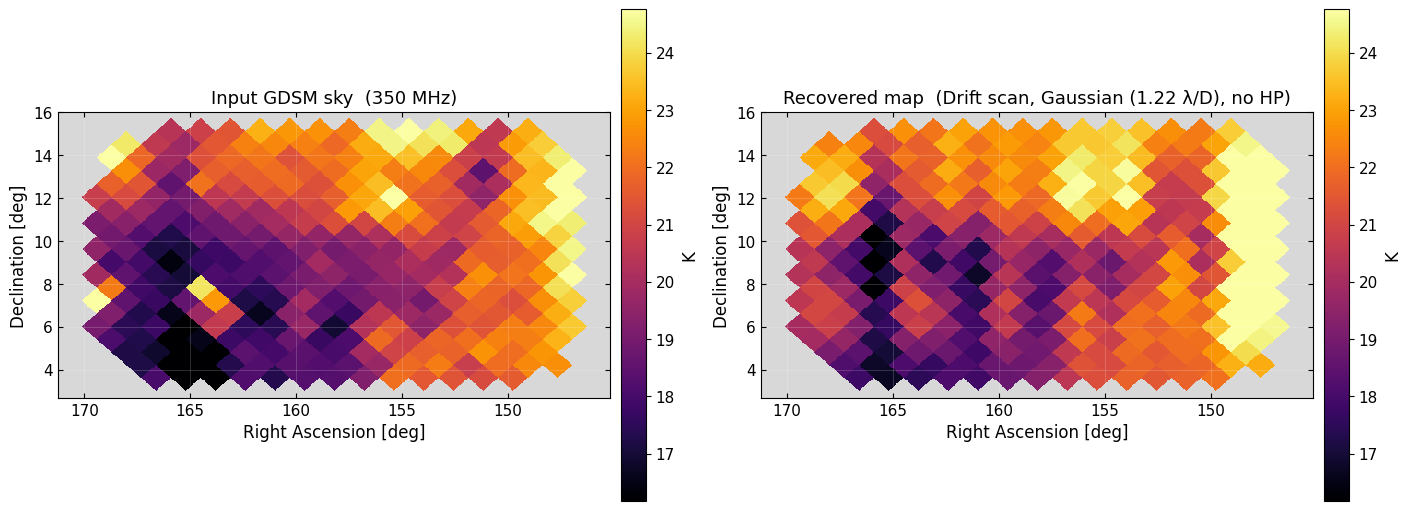

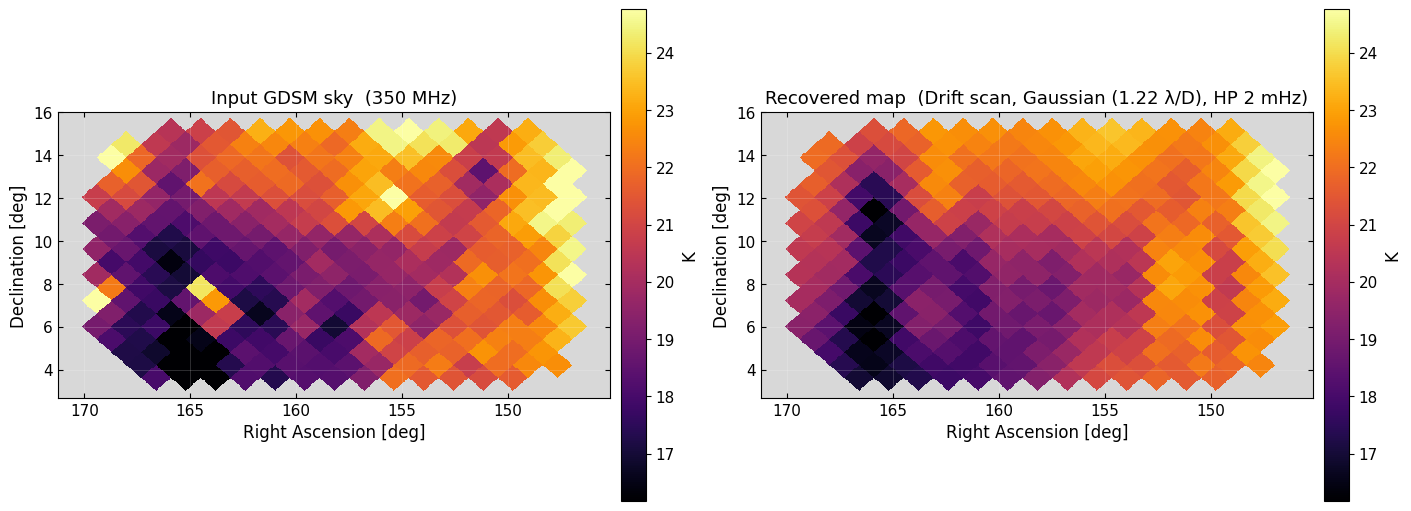

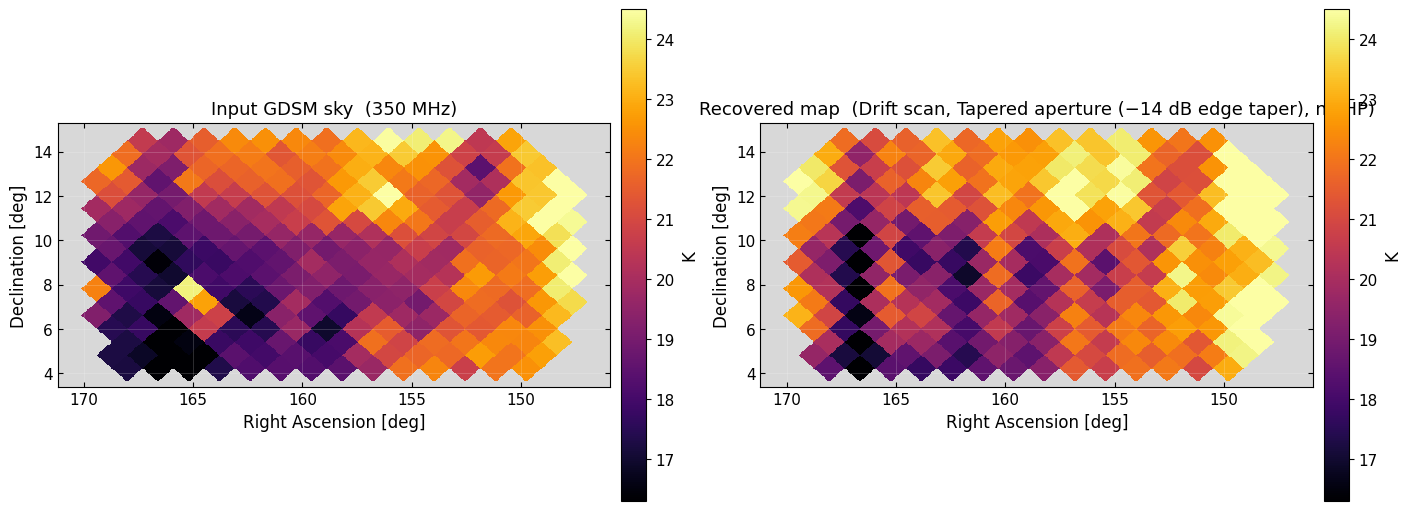

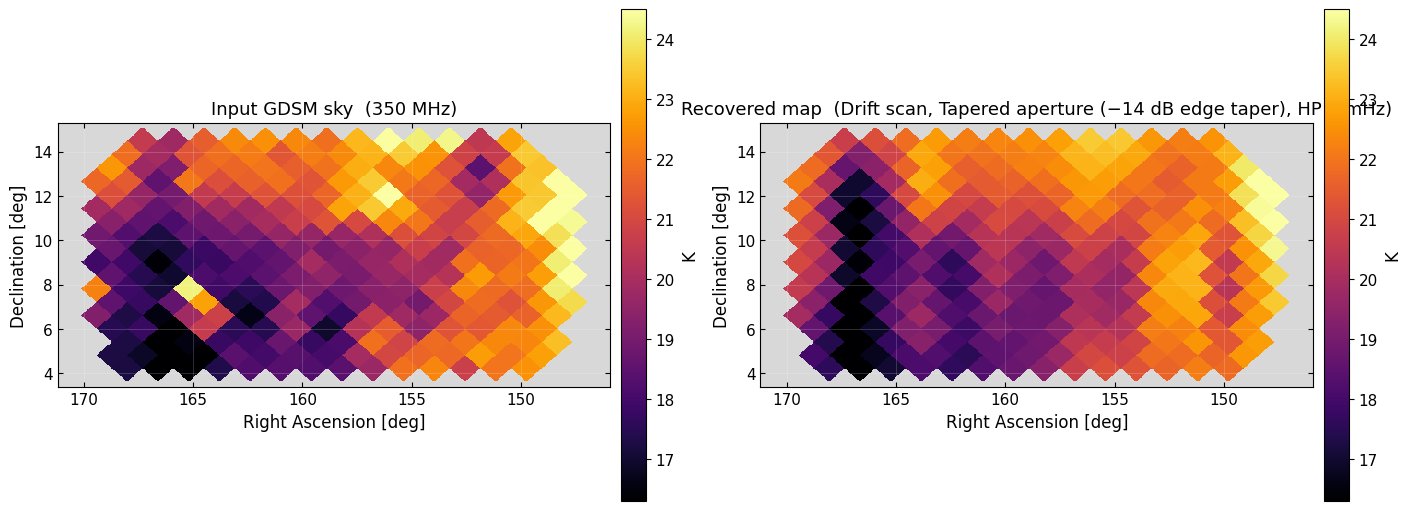

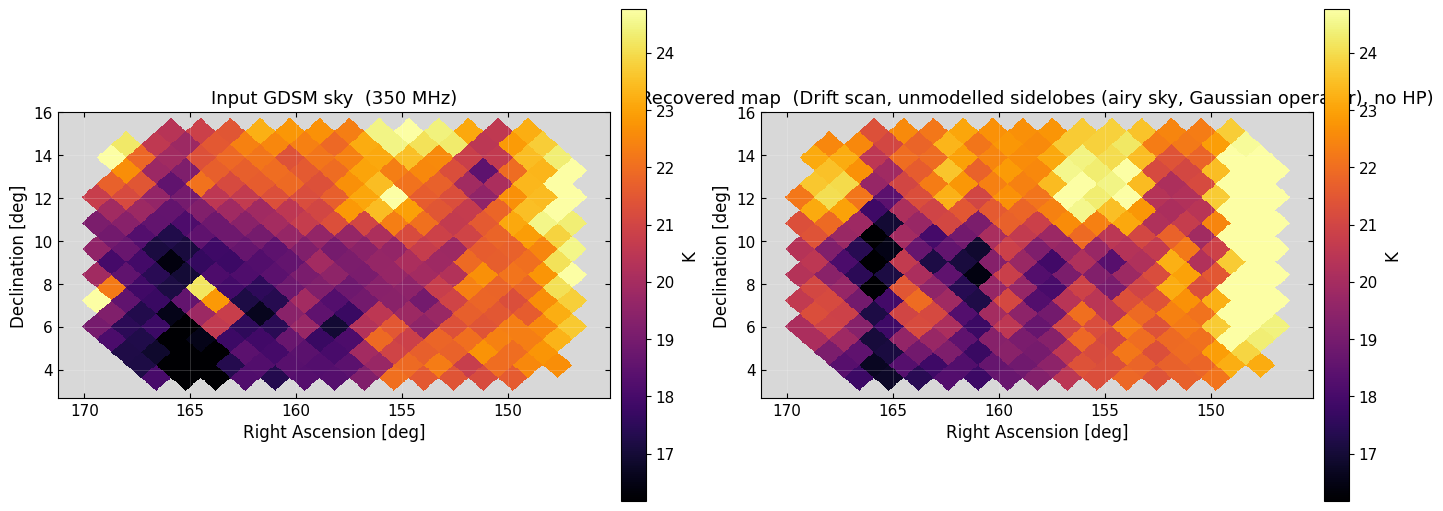

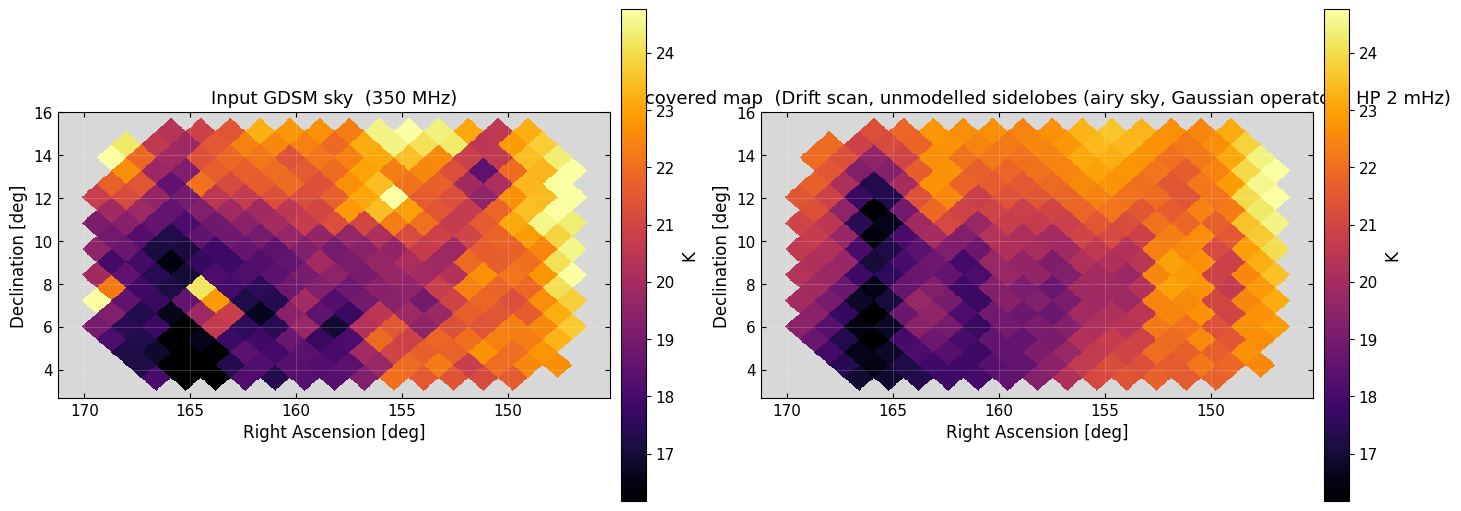

In [8]:
SCENARIO_LABELS = {
    "gauss": BEAMS["gauss"]["label"],
    "airy": BEAMS["airy"]["label"],
    "mismatch": "unmodelled sidelobes (airy sky, Gaussian operator)",
}
for tag, label in SCENARIO_LABELS.items():
    for hp_label, suffix in [("no HP", "noHP"), ("HP 2 mHz", "HP")]:
        fig = plot_map_compare(
            sky_est=results[(tag, hp_label)],
            sky_truth=truths[tag],
            nside=sky_Nside_map,
            pixel_indices=SCENARIO_PIX[tag],
            freq_mhz=freq_list[0],
            strategy_name=f"Drift scan, {label}, {hp_label}",
            savepath=f"figures/map_ska_drift_{tag}_{suffix}.png",
        )
        plt.show()


## Power spectra

Two complementary views of the same six recoveries:

- **1D pseudo-$C_\ell$** on each scenario's own observed patch (leading-order
  mask correction by $1/f_{\rm sky}$, recipe from
  `examples/DSA/scripts/compare_power_spectra.py`), with the transfer function
  $T_\ell = C_\ell^{\rm rec}/C_\ell^{\rm truth}$ and the correlation coefficient
  $r_\ell = C_\ell^\times/\sqrt{C_\ell^{\rm rec}C_\ell^{\rm truth}}$. $T_\ell$
  only checks total power; $r_\ell$ tests whether the recovered modes are
  *phase-aligned* with truth — $r_\ell < 1$ means genuine noise/leakage power.
- **2D flat-sky** power of the *residual* (rec − truth). The drift geometry is
  anisotropic: 1/f drift varies along RA (= time), and because nights are
  sidereal-offset all three Dec rows see a given RA at the same within-night
  time — so the drift residual is coherent **across Dec** and shows up as a band
  at low $\ell_{\rm Dec}$ extended in $\ell_{\rm RA}$, which the HP filter
  should suppress. $C_\ell$ integrates this direction dependence away, which is
  why the 2D view is worth having.

The patch is tiny ($f_{\rm sky}\approx 0.006$), so the low-$\ell$ bins average
very few modes — read them qualitatively.

In [ ]:
# 1D: pseudo-Cl on each scenario's own observed patch, leading-order
# mask-corrected by 1/f_sky (recipe from
# examples/DSA/scripts/compare_power_spectra.py). Three statistics:
#   Cl^rec    recovered angular power vs the masked GDSM truth
#   T_l       transfer function Cl^rec / Cl^truth (total power only)
#   r_l       correlation Cl^cross / sqrt(Cl^rec Cl^truth) — phase
#             alignment with truth, insensitive to amplitude errors.
LMAX = 3 * sky_Nside_map - 1
ell = np.arange(LMAX + 1)
bin_edges = np.unique(np.logspace(np.log10(2), np.log10(LMAX + 1), 11)
                      .astype(int))


def embed_patch(values, pixel_indices, nside, fill=0.0):
    full = np.full(hp.nside2npix(nside), fill, dtype=np.float64)
    full[pixel_indices] = values
    return full


def masked_cls(map1, mask, lmax, map2=None):
    m = mask.astype(np.float64)
    fsky = m.mean()

    def _zero_mean_masked(x):
        return (x - (x * m).sum() / m.sum() * m) * m

    maps = [_zero_mean_masked(map1)]
    if map2 is not None:
        maps.append(_zero_mean_masked(map2))
    return hp.anafast(*maps, lmax=lmax) / fsky


def bin_cls(cl, edges):
    centres = 0.5 * (edges[:-1] + edges[1:])
    binned = np.array([cl[(ell >= lo) & (ell < hi)].mean()
                       for lo, hi in zip(edges[:-1], edges[1:])])
    return centres, binned


pk1d = {}
for tag in SCENARIOS:
    mask = np.zeros(hp.nside2npix(sky_Nside_map))
    mask[SCENARIO_PIX[tag]] = 1.0
    l_c, cl_truth_b = bin_cls(masked_cls(sky_truth_full, mask, LMAX),
                              bin_edges)
    for hp_label in ("no HP", "HP 2 mHz"):
        est_full = embed_patch(results[(tag, hp_label)], SCENARIO_PIX[tag],
                               sky_Nside_map)
        _, cl_rec_b = bin_cls(masked_cls(est_full, mask, LMAX), bin_edges)
        _, cl_x_b = bin_cls(masked_cls(est_full, mask, LMAX,
                                       map2=sky_truth_full), bin_edges)
        pk1d[(tag, hp_label)] = dict(
            l=l_c, truth=cl_truth_b, rec=cl_rec_b,
            T=cl_rec_b / cl_truth_b,
            r=cl_x_b / np.sqrt(np.abs(cl_rec_b) * np.abs(cl_truth_b)),
            fsky=mask.mean(),
        )

HP_COLORS = {"no HP": "tab:red", "HP 2 mHz": "tab:blue"}
ell_beam = 180.0 / BEAMS["airy"]["fwhm"]
marker_kw = dict(marker="o", ms=5, mec="white", mew=0.7, lw=1.8)

fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True, sharey="row",
                         constrained_layout=True)
for col, tag in enumerate(SCENARIOS):
    ax_cl, ax_T, ax_r = axes[:, col]
    ax_cl.loglog(pk1d[(tag, "no HP")]["l"], pk1d[(tag, "no HP")]["truth"],
                 color="k", lw=6, alpha=0.25, solid_capstyle="round",
                 label="GDSM truth")
    for hp_label, color in HP_COLORS.items():
        d = pk1d[(tag, hp_label)]
        ax_cl.loglog(d["l"], d["rec"], color=color, label=hp_label,
                     **marker_kw)
        ax_T.semilogx(d["l"], d["T"], color=color, **marker_kw)
        ax_r.semilogx(d["l"], d["r"], color=color, **marker_kw)
    for ax in (ax_cl, ax_T, ax_r):
        ax.axvline(ell_beam, color="0.4", ls="--", lw=1.2)
        ax.grid(alpha=0.3)
    ax_T.axhline(1.0, color="k", lw=1, alpha=0.6)
    ax_r.axhline(1.0, color="k", lw=1, alpha=0.6)
    ax_r.axhline(0.0, color="k", ls=":", lw=0.8, alpha=0.4)
    ax_cl.set_title(SCENARIO_LABELS[tag], fontsize=10)
    ax_r.set_xlabel(r"multipole $\ell$")

axes[0, 0].set_ylabel(r"$C_\ell$  [K$^2$]")
axes[1, 0].set_ylabel(r"$T_\ell = C_\ell^{\rm rec}/C_\ell^{\rm truth}$")
axes[1, 0].set_ylim(0.0, 2.2)
axes[2, 0].set_ylabel(r"$r_\ell = C_\ell^\times/\sqrt{C_\ell^{\rm rec}"
                      r"C_\ell^{\rm truth}}$")
axes[2, 0].set_ylim(-0.2, 1.1)
axes[0, 0].legend(loc="lower left", fontsize=9)
fsky_all = [pk1d[(t, "no HP")]["fsky"] for t in SCENARIOS]
fig.suptitle(f"Angular power spectra on each scenario's own patch "
             f"(f_sky ≈ {min(fsky_all):.4f}–{max(fsky_all):.4f}; dashed = "
             r"$\ell_{\rm beam}\approx$" + f"{ell_beam:.0f})")
fig.savefig("figures/power_spectra_1d.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# 2D: flat-sky power spectrum of the RESIDUAL (rec − truth) on the drift
# strip. The drift geometry is anisotropic — 1/f drift varies along RA
# (= time), and because consecutive nights are sidereal-offset, all three
# Dec rows see a given RA at the same within-night time, so the drift
# residual is coherent ACROSS Dec: expect a band at low l_Dec extended in
# l_RA. That directional statement is exactly what Cl integrates away.
# Recipe: nearest-pixel sample of the residual onto a regular (RA, Dec)
# grid over the strip's bounding box (no interpolation, so nothing leaks
# across the mask edge), zero-mean on the mask, Hann-taper the box, FFT.
# Qualitative diagnostic: the irregular mask edge is not deconvolved.
RES_DEG = 0.45  # grid step, ~half a healpix pixel at nside 64


def flat_power_2d(res_full, pixel_indices, nside, res_deg=RES_DEG):
    ra_p, dec_p = hp.pix2ang(nside, pixel_indices, lonlat=True)
    pad = 1.0
    ra = np.arange(ra_p.min() - pad, ra_p.max() + pad, res_deg)
    dec = np.arange(dec_p.min() - pad, dec_p.max() + pad, res_deg)
    RA, DEC = np.meshgrid(ra, dec)
    gpix = hp.ang2pix(nside, RA, DEC, lonlat=True)
    observed = np.zeros(hp.nside2npix(nside), dtype=bool)
    observed[pixel_indices] = True
    m = observed[gpix].astype(np.float64)
    vals = res_full[gpix] * m
    vals -= vals.sum() / m.sum() * m

    win = (np.outer(np.hanning(len(dec)), np.hanning(len(ra))) * m)
    # Physical grid steps: RA compressed by cos(dec) at the strip centre.
    dx = res_deg * np.cos(np.radians(dec_p.mean()))
    dy = res_deg
    F = np.fft.fftshift(np.fft.fft2(vals * win))
    # P(l) in K^2 deg^2, normalized by the window power.
    P = np.abs(F) ** 2 * (dx * dy) ** 2 / ((win ** 2).sum() * dx * dy)
    # Flat-sky multipole: l = 2π × (cycles/rad) = 360 × (cycles/deg).
    l_ra = 360.0 * np.fft.fftshift(np.fft.fftfreq(len(ra), d=dx))
    l_dec = 360.0 * np.fft.fftshift(np.fft.fftfreq(len(dec), d=dy))
    return l_ra, l_dec, P


fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), constrained_layout=True,
                         sharex=True, sharey=True)
panels = {}
for col, tag in enumerate(SCENARIOS):
    res_truth_full = embed_patch(truths[tag], SCENARIO_PIX[tag],
                                 sky_Nside_map)
    for row, hp_label in enumerate(("no HP", "HP 2 mHz")):
        est_full = embed_patch(results[(tag, hp_label)], SCENARIO_PIX[tag],
                               sky_Nside_map)
        panels[(tag, hp_label)] = flat_power_2d(
            est_full - res_truth_full, SCENARIO_PIX[tag], sky_Nside_map)

logP_all = np.concatenate([np.log10(P.ravel() + 1e-30)
                           for _, _, P in panels.values()])
vmax = np.percentile(logP_all, 99.5)
vmin = vmax - 6

for col, tag in enumerate(SCENARIOS):
    for row, hp_label in enumerate(("no HP", "HP 2 mHz")):
        ax = axes[row, col]
        l_ra, l_dec, P = panels[(tag, hp_label)]
        im = ax.pcolormesh(l_ra, l_dec, np.log10(P + 1e-30),
                           vmin=vmin, vmax=vmax, cmap="magma",
                           shading="nearest", rasterized=True)
        ax.set_xlim(-200, 200)
        ax.set_ylim(-200, 200)
        ax.axhline(0, color="w", lw=0.4, alpha=0.4)
        ax.axvline(0, color="w", lw=0.4, alpha=0.4)
        if row == 0:
            ax.set_title(SCENARIO_LABELS[tag], fontsize=10)
        if col == 0:
            ax.set_ylabel(f"{hp_label}\n" + r"$\ell_{\rm Dec}$")
        if row == 1:
            ax.set_xlabel(r"$\ell_{\rm RA}$")

        # Stripe anisotropy: mean residual power in the low-l_Dec band
        # (coherent across Dec, varying along RA — the drift signature)
        # over the transposed low-l_RA band. > 1 means drift stripes
        # dominate the residual; the HP filter should pull it toward 1.
        band = 30.0
        dec_band = P[np.abs(l_dec) < band, :].mean()
        ra_band = P[:, np.abs(l_ra) < band].mean()
        ax.text(0.03, 0.95, f"stripe ratio = {dec_band / ra_band:.1f}",
                transform=ax.transAxes, va="top", fontsize=9,
                color="white")

fig.colorbar(im, ax=axes, shrink=0.85,
             label=r"$\log_{10} P(\ell_{\rm RA}, \ell_{\rm Dec})$"
                   r"  [K$^2$ deg$^2$]")
fig.suptitle("2D flat-sky power of the residual (rec − truth): 1/f drift "
             "→ band at low $\\ell_{\\rm Dec}$, extended in "
             "$\\ell_{\\rm RA}$")
fig.savefig("figures/power_spectra_2d.png", dpi=200, bbox_inches="tight")
plt.show()

## Archive results

Each experiment's figures + a one-paragraph setup description go into a numbered
PDF under `results/`, so the record survives notebook re-runs:

- **001** — short drift, matched beams (Gaussian vs tapered aperture), HP comparison.
- **002** — beam mismatch: unmodelled sidelobes (tapered-aperture sky through a
  Gaussian operator), against matched-airy with identical noise.


In [9]:
setup_common = (
    f"Short drift scan at {freq_list[0]} MHz: SKA-Mid-like 15 m dish at the "
    f"Karoo site, parked at az = 0°, elevations {ELEVATIONS} on 3 consecutive "
    f"sidereal nights (1 h/night, dt = {DT:.0f} s, 5400 samples), GDSM sky at "
    f"nside = {sky_Nside_map}, default 1/f gain noise + fractional white noise "
    f"{WHITE_VAR:g}, per-night seeds {SEED}+night shared across beams. "
    f"Wiener map-maker with beam-smoothed-truth prior; solved without HP "
    f"filter and with a 2 mHz cutoff."
)

save_results_pdf(
    1, "short-drift-matched-beams",
    "Matched forward/inverse beams: Gaussian (FWHM 4.0°) vs tapered aperture "
    "(FWHM 3.8°, first sidelobe −23 dB). " + setup_common,
    ["figures/beam_profiles.png", "figures/drift_tracks.png",
     "figures/tod_night0.png"]
    + [f"figures/map_ska_drift_{t}_{s}.png"
       for t in ("gauss", "airy") for s in ("noHP", "HP")],
    rms_table=[r for r in rms_rows if not r[0].startswith("mismatch")],
)

save_results_pdf(
    2, "beam-mismatch-unmodelled-sidelobes",
    "Beam mismatch: TOD simulated with the tapered-aperture beam but map made "
    "with the Gaussian operator, so the sidelobe pickup is an unmodelled "
    "systematic. Identical noise realizations to the matched cases — compare "
    "against the matched-airy rows. " + setup_common,
    [f"figures/map_ska_drift_mismatch_{s}.png" for s in ("noHP", "HP")],
    rms_table=[r for r in rms_rows
               if r[0].startswith(("mismatch", "airy"))],
)


Archived results to results/001_short-drift-matched-beams.pdf
Archived results to results/002_beam-mismatch-unmodelled-sidelobes.pdf


'results/002_beam-mismatch-unmodelled-sidelobes.pdf'

## Next steps

- Drift strip near the galactic plane: the real sidelobe stress test — the rings
  sweep through emission orders of magnitude brighter, and the beam-mismatch
  systematic should grow accordingly.
- Measured/EM-simulated primary beam: `katbeam` (SARAO's MeerKAT model) covers
  UHF (544–1088 MHz) and L band, not 350 MHz — so either an SKA-Mid Band 1 EM
  simulation, or accept the tapered-aperture model as the Band 1 stand-in.
- Asymmetric beam (elliptical main lobe / feed-leg diffraction spikes): in drift
  mode the beam orientation on the sky is nearly constant, so asymmetries do not
  average down — expect this to matter more than for scanning strategies.
- More nights / more elevation settings (an "elevation cascade" analogue) to widen
  the Dec strip, add beam-orientation diversity per pixel, and average down the
  noise — the current 3 × 1 h residual spectra are noise-dominated past the
  beam scale, so more integration time is the first lever on signal-to-noise.
- Longer nights: a full 12 h drift covers 180° of RA for free — the operator gets
  large but the strategy's real appeal is exactly this survey speed.
- Study the HP-cutoff trade-off properly (sweep cutoff vs. residual RMS and
  per-ℓ transfer function, as in `examples/DSA/scripts/`).
